In [1]:
# Create by antoine.caillebotte@inrae.fr
from time import time
from sdg4varselect.miscellaneous import time2string

import sdg4varselect.plot as sdgplt
import pickle
import numpy as np

from sdg4varselect.solver import shrink_support
from one_run import (
    sample,
    estim,
    get_random_params0,
    params_star_weibull,
    params_star_stack,
    N_IND,
    DIM_COV,
    estim_solver,
)
from sdg4varselect.miscellaneous import step_message, bic_final_estim_from_list

from sdg4varselect import jrd, jnp


kwargs_run_GD = {
    "prox_regul": 1.29e-3,
    "proximal_operator": False,
}


def clever_regularization_path(parameters0, path, prng_key, nrep=1, verbatim=False):
    list_res = []
    list_solver = []
    data_set, key = sample(params_star_weibull, prng_key)

    for i in range(len(path)):
        print(step_message(i, len(path)), end="\r" if not verbatim else "\n")

        kwargs_run_GD["prox_regul"] = path[i]
        kwargs_run_GD["proximal_operator"] = True
        res, solver, key = estim(
            data_set,
            parameters0,
            key,
            niter=800,
            kwargs_run_GD=kwargs_run_GD,
            verbatim=verbatim,
            activate_fim=True,
            activate_jac_approx=True,
            lr=1e-4,
            # Grad
            plateau_grad=600,
            plateau_grad_size=100,
            scale_grad=1,
            # Jac
            plateau_jac=600,
            plateau_jac_size=1000,
            scale_jac=1,
            # Fim
            plateau_fim=600,
            plateau_fim_size=2000,
            scale_fim=1,
        )

        list_solver.append(solver)
        list_res.append(res)

        print(f"#beta = {solver.get_number_of_nonzero(p=DIM_COV)}")

        if solver.get_number_of_nonzero(p=DIM_COV) == 0:
            for k in range(len(path) - i - 1):
                print(
                    step_message(i + k, len(path)), end="\r" if not verbatim else "\n"
                )
                list_solver.append(list_solver[-1])
                list_res.append(list_res[-1])

            print(f"break at {path[i]}")
            break

    return list_solver, list_res, key


def final_estim(solver, parameters0, prox_regul, verbatim=False):
    kwargs_run_GD["prox_regul"] = prox_regul
    kwargs_run_GD["proximal_operator"] = False
    p0 = parameters0.copy()

    solver_select, mask_select = shrink_support(solver, "beta", DIM_COV)
    p0["beta"] = jnp.where(mask_select[-DIM_COV:], p0["beta"], 0)
    solver_select.reset_solver()
    solver_select.theta_reals1d = p0

    res, solver_select = estim_solver(
        solver_select,
        niter=800,
        kwargs_run_GD=kwargs_run_GD,
        verbatim=verbatim,
        activate_fim=True,
        activate_jac_approx=True,
        lr=1e-4,
        # Grad
        plateau_grad=600,
        plateau_grad_size=100,
        scale_grad=1,
        # Jac
        plateau_jac=600,
        plateau_jac_size=2000,
        scale_jac=1,
        # Fim
        plateau_fim=600,
        plateau_fim_size=1000,
        scale_fim=0.9,
    )
    return res, solver_select


# ====================================================== #
# ================ REGULARIZATION PATH ================= #
# ====================================================== #
params0, prng_key = get_random_params0(jrd.PRNGKey(int(time())), error=0.2)

# params0["mu1"] = params_star_weibull.mu1 + 0.1
# params0["mu2"] = params_star_weibull.mu2
# params0["mu3"] = params_star_weibull.mu3
# params0["gamma2_1"] = params_star_weibull.gamma2_1
# params0["gamma2_2"] = params_star_weibull.gamma2_2

# params0["alpha"] = params_star_weibull.alpha


print(f"params0 = {params0}")

# pour DIM_COV < 100
# lbd_set = 10 ** jnp.linspace(-1, -0.5, num=50)  # [10**-0.75]  #
# pour DIM_COV = 1000
lbd_set = 10 ** jnp.linspace(-2, 0, num=15)
# lbd_set = [0.3]
# [0.1, 0.15]  # , 10**-1.5]  # 10 ** jnp.linspace(-2, -0.5, num=50)  #


nrun = 1
ls, lr = [], []
for k in range(nrun):
    time_start = time()
    s, r, prng_key = clever_regularization_path(params0, lbd_set, prng_key)
    print(f"REGULARIZATION PATH TIME: {time2string(time() - time_start)}")

    ls.append(s)
    lr.append(r)


# final_res, final_solver = lr[0][0], ls[0][0]

bic, theta_reg = bic_final_estim_from_list(ls, lr, N_IND, DIM_COV, verbatim=True)
# ============================================ #
# ================ INFERENCE ================= #
# ============================================ #
bic_argmin = np.argmin(bic)
res_selection = lr[0][bic_argmin]
solver_selection = ls[0][bic_argmin]

final_res, final_solver = final_estim(
    solver_selection, params0, lbd_set[bic_argmin], verbatim=True
)

# _, _ = sdgplt.plot_regularization_path(theta_reg, lbd_set, bic)


# ====================================================== #
def extract_data(res, solver):
    latent_variables = ls[0][bic_argmin].latent_variables
    for var in latent_variables.values():
        var.likelihood = None

    data = {
        "theta": res.theta,
        "grad_precond": res.grad_precond,
        "likelihood": res.likelihood,
        "theta_diff": res.theta_diff,
        "latent_variables": ls[0][bic_argmin].latent_variables,
        "jac_min": [res.jac[i].min() for i in range(len(res.jac))],
        "jac_max": [res.jac[i].max() for i in range(len(res.jac))],
        "fim_det": [jnp.linalg.det(x) for x in res.fisher_info],
        "fim_vp": np.array([jnp.linalg.eigvalsh(x) for x in res.fisher_info]),
    }
    return data


# data_selection = extract_data(res_selection, ls[0][bic_argmin])
# data_final = extract_data(final_res, final_solver)

# step_size = {
#     "jac": final_solver.step_size,
#     "fisher": final_solver.step_size_fisher,
#     "gradient": final_solver.step_size_grad,
# }

# data = {
#     "res_selection": data_selection,
#     "res_final": data_final,
#     "bic": bic,
#     "theta_reg": theta_reg,
#     "lbd_set": lbd_set,
#     "params_names": ls[0][0].params_names,
#     "step_size": step_size,
#     "DIM_COV": DIM_COV,
#     "N_IND": N_IND,
#     "params_star_stack": params_star_stack,
# }

# with open("res_selection.pkl", "wb") as f:
#     pickle.dump(data, f)

# print("RESULT SAVED !")


# params_names = solver_selection.params_names


# fig = sdgplt.figure()
# solver_selection.step_size.plot(label="Jac step size")
# solver_selection.step_size_fisher.plot(label="FIM step size")
# solver_selection.step_size_grad.plot(label="gradient step size")
# sdgplt.plt.legend()

# _, _ = sdgplt.plot_params_grad(
#     res_selection.theta,
#     res_selection.grad_precond,
#     np.array(params_star_stack),
#     p=DIM_COV,
#     names=params_names,
#     logscale=False,
# )

# _, _ = sdgplt.plot_params_hd(res_selection.theta, p=DIM_COV, location="right")

# print(res_selection.theta[-1][:DIM_COV])


# # =========================#
# fig = sdgplt.figure()
# final_solver.step_size.plot(label="Jac step size")
# final_solver.step_size_fisher.plot(label="FIM step size")
# final_solver.step_size_grad.plot(label="gradient step size")
# sdgplt.plt.legend()

# _, _ = sdgplt.plot_params_grad(
#     final_res.theta,
#     final_res.grad_precond,
#     np.array(params_star_stack),
#     p=DIM_COV,
#     names=params_names,
#     logscale=False,
# )

# _, _ = sdgplt.plot_params_hd(final_res.theta, p=DIM_COV, location="right")

# print(final_res.theta[-1][:DIM_COV])

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


params0 = {'mu1': 0.4470269978046417, 'mu2': 48.04210662841797, 'mu3': 2.76698237657547, 'gamma2_1': 0.00024112120270729066, 'gamma2_2': 1.7824463844299316, 'sigma2': 8.607746958732605e-05, 'alpha': 4.533215165138245, 'beta': Array([-0.21 , -0.563,  0.809, -0.172, -0.619, -0.913, -0.189,  0.361,
       -0.334, -0.219, -0.628, -0.052, -0.408,  0.415,  0.53 , -0.672,
        0.691, -0.589,  0.417, -0.883,  0.188,  0.915, -0.709, -0.431,
        0.797, -0.253,  0.654, -0.933,  0.309,  0.658, -0.993, -0.863,
        0.954,  0.95 ,  0.177,  0.3  , -0.095, -0.376,  0.056, -0.82 ,
       -0.523, -0.963, -0.983, -0.398,  0.262,  0.552,  0.535, -0.924,
       -0.131,  0.581,  0.958, -0.907,  0.882,  0.359,  0.893,  0.929,
       -0.975, -0.892, -0.051,  0.733, -0.079, -0.61 , -0.395, -0.118,
        0.297, -0.637, -0.742, -0.91 ,  0.81 ,  0.047, -0.341, -0.559,
        0.964,  0.389,  0.967,  0.222,  0.25 , -0.631, -0.938,  0.848,
        0.559,  0.248, -0.041, -0.697,  0.4  , -0.499,  0.657,  

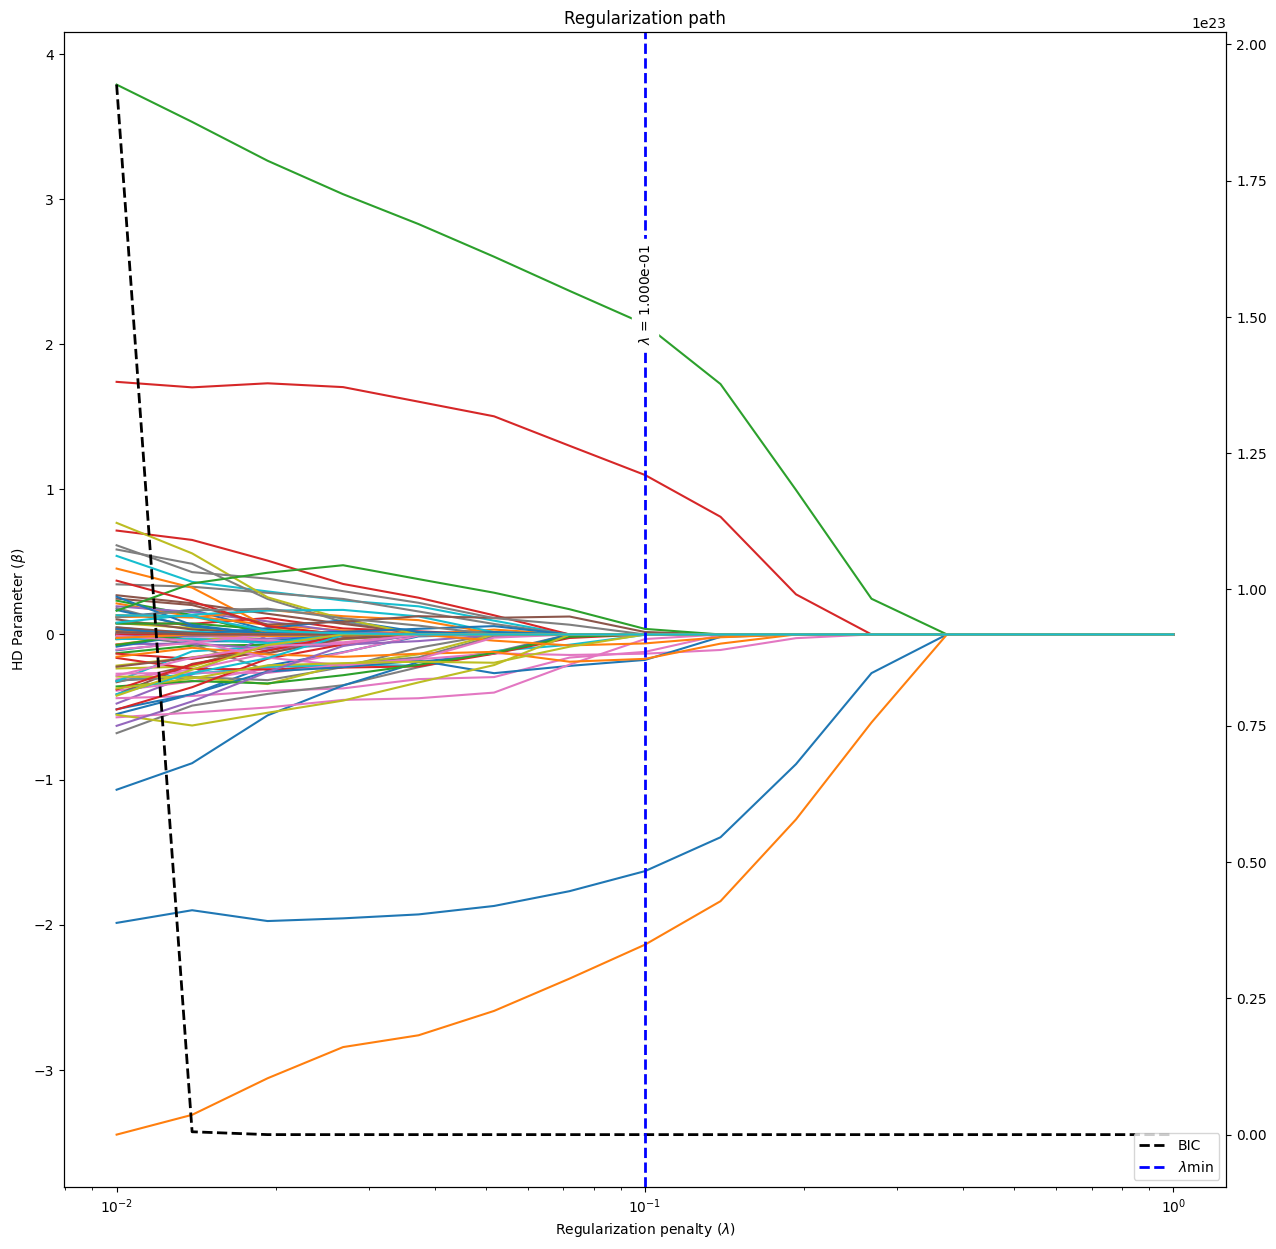

In [2]:
_, _ = sdgplt.plot_regularization_path(theta_reg, lbd_set, bic)

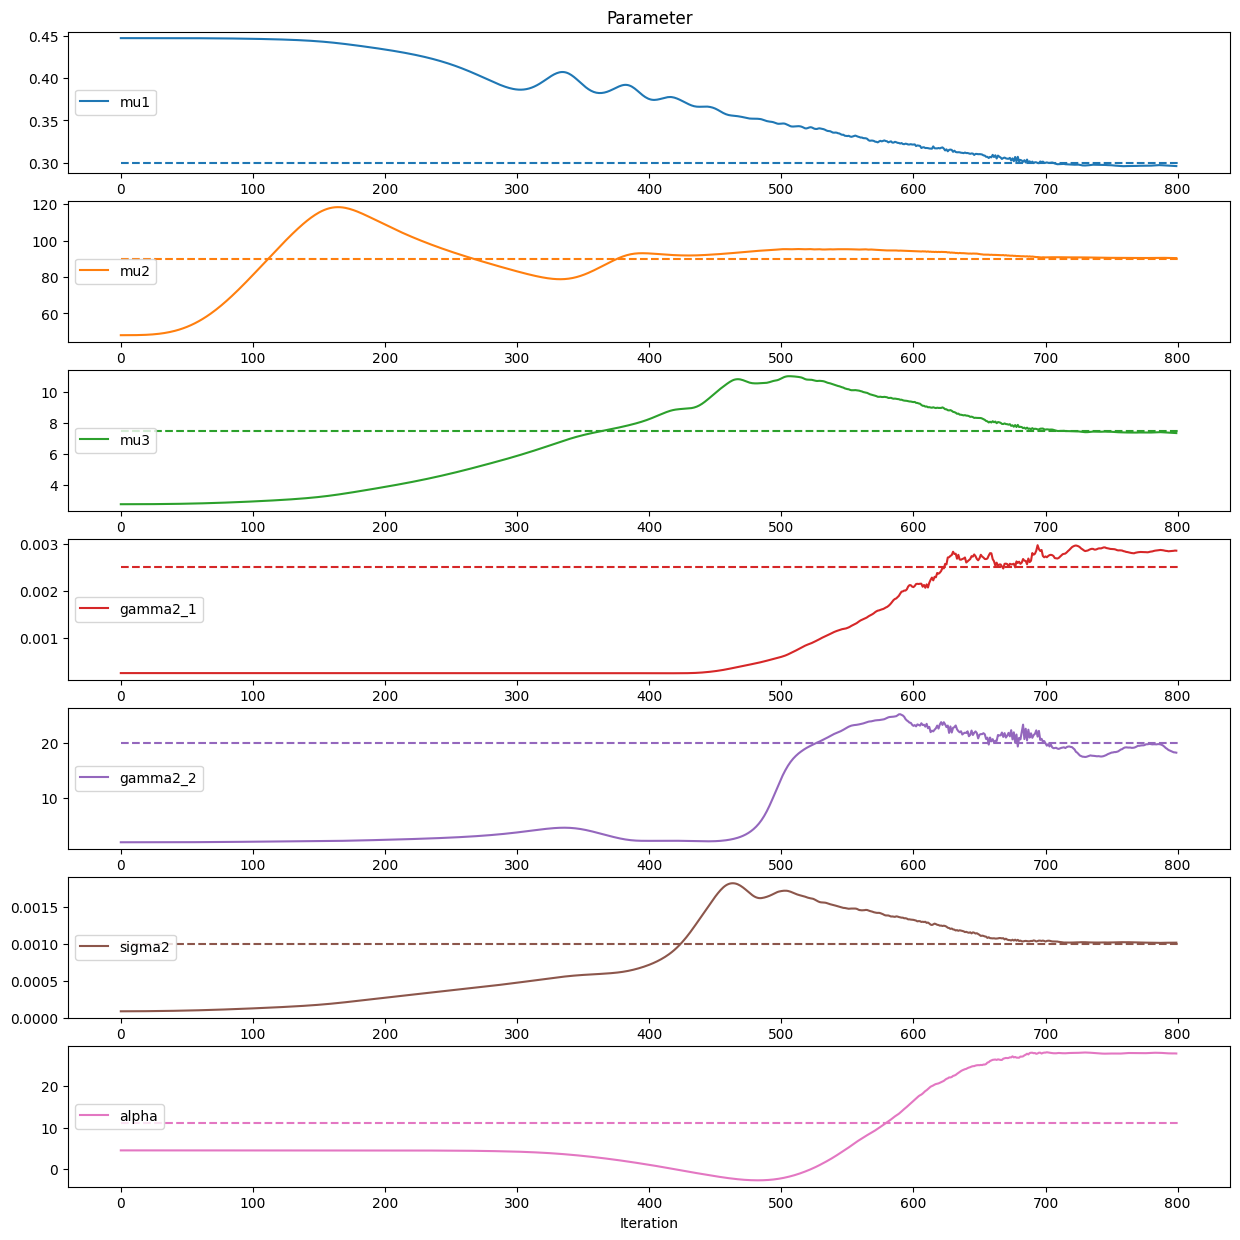

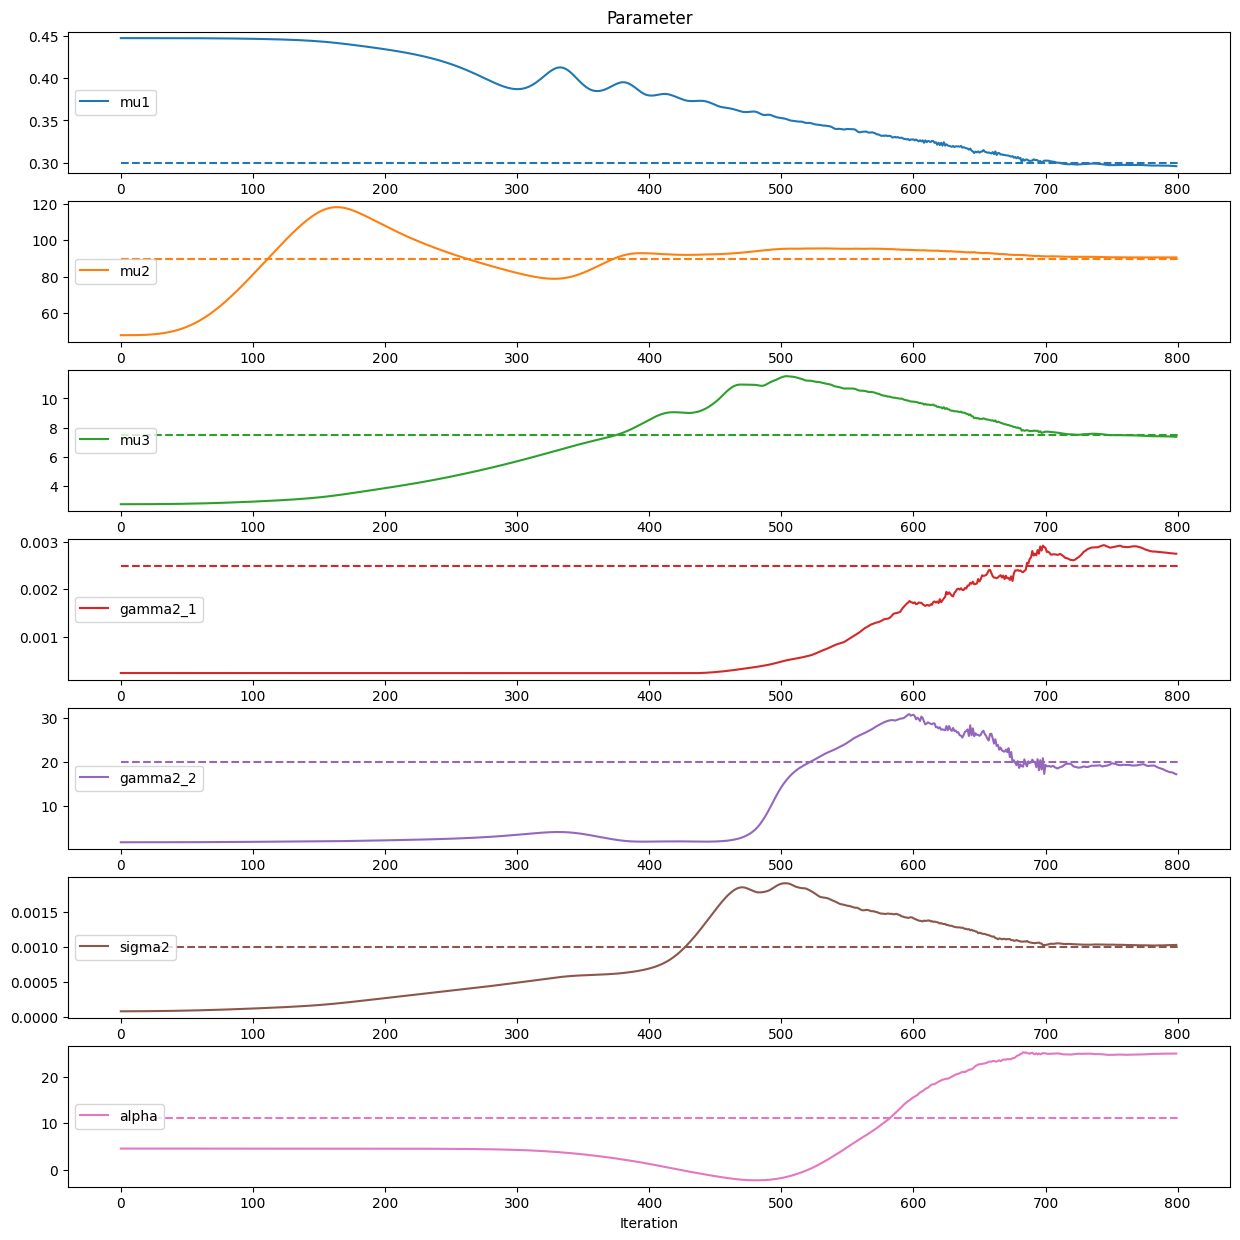

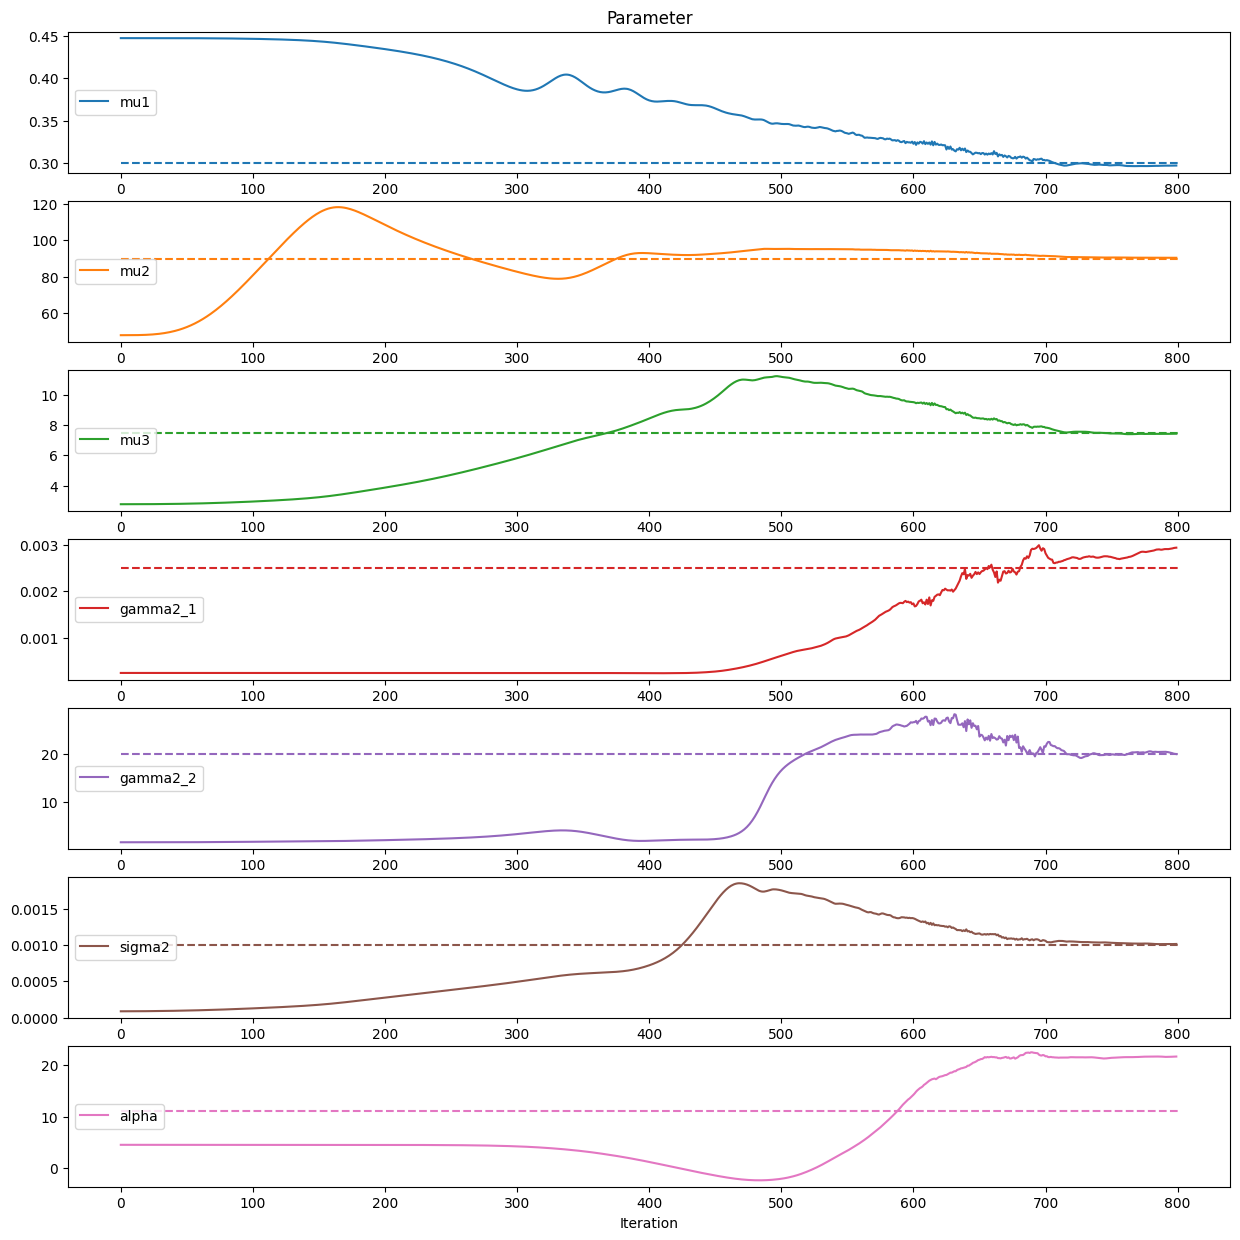

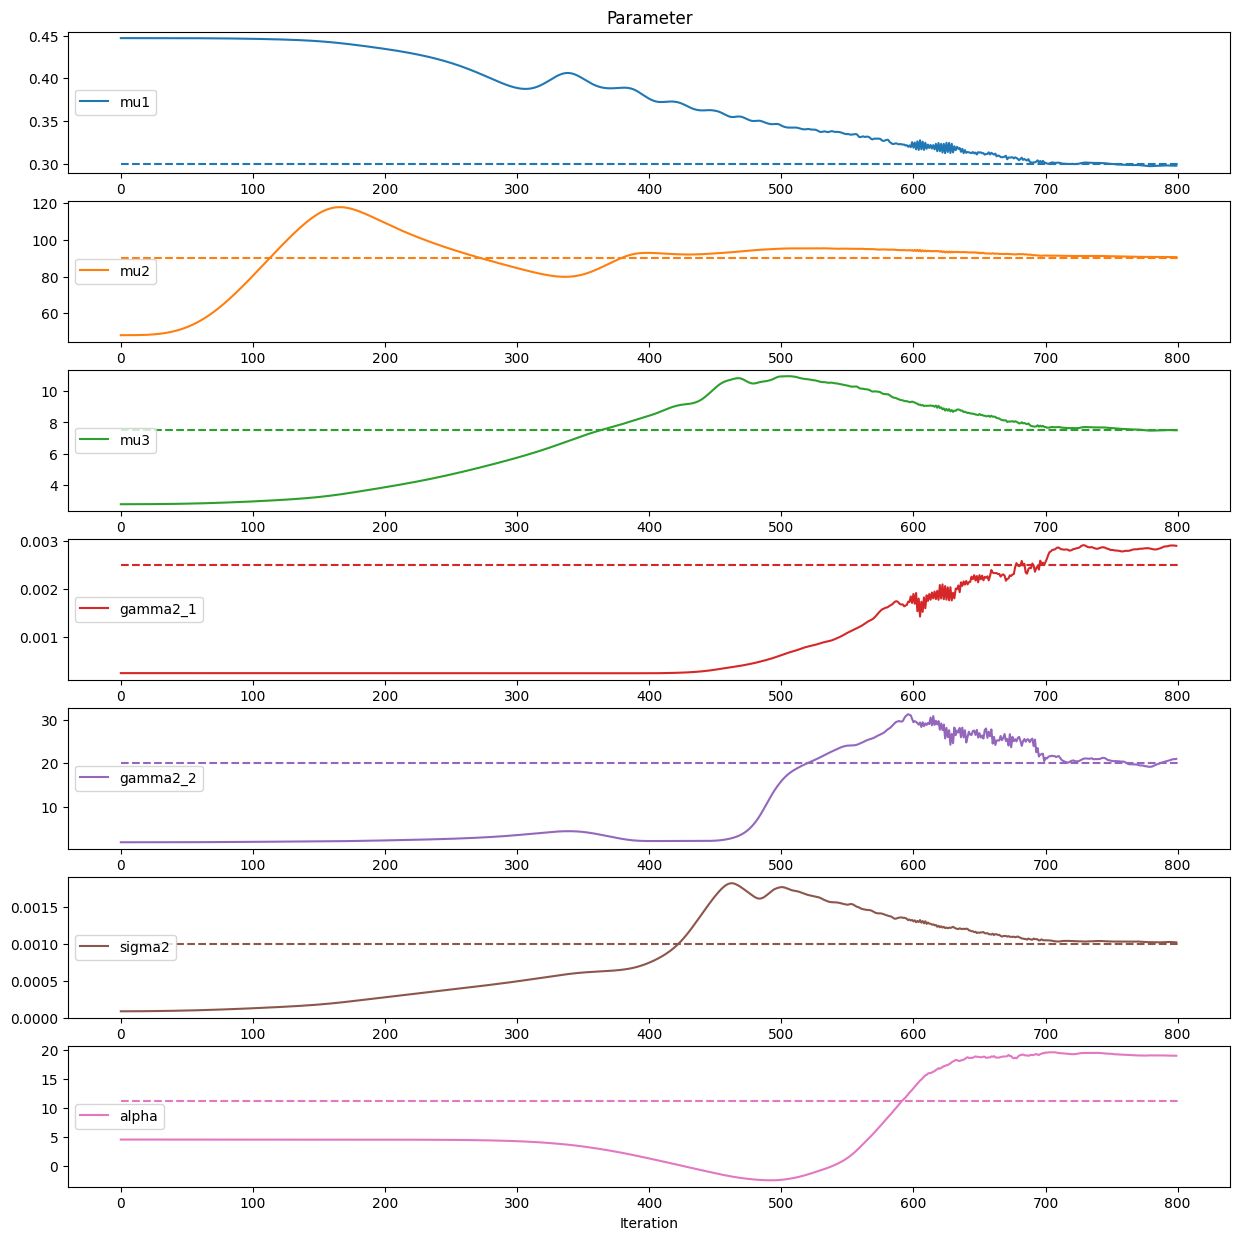

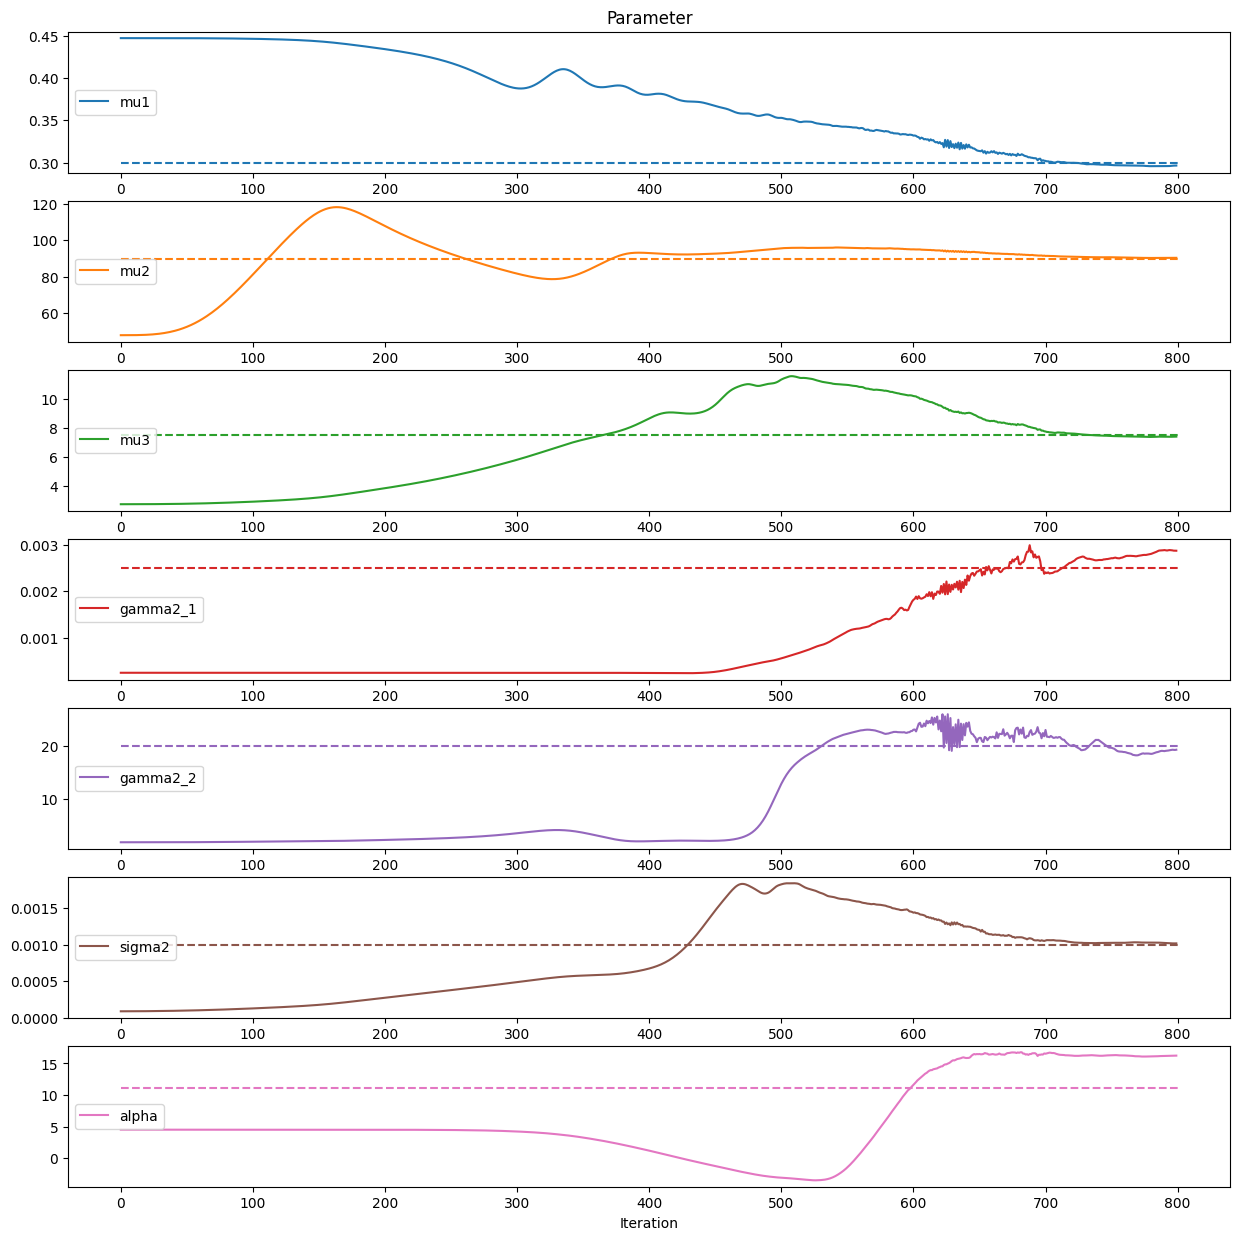

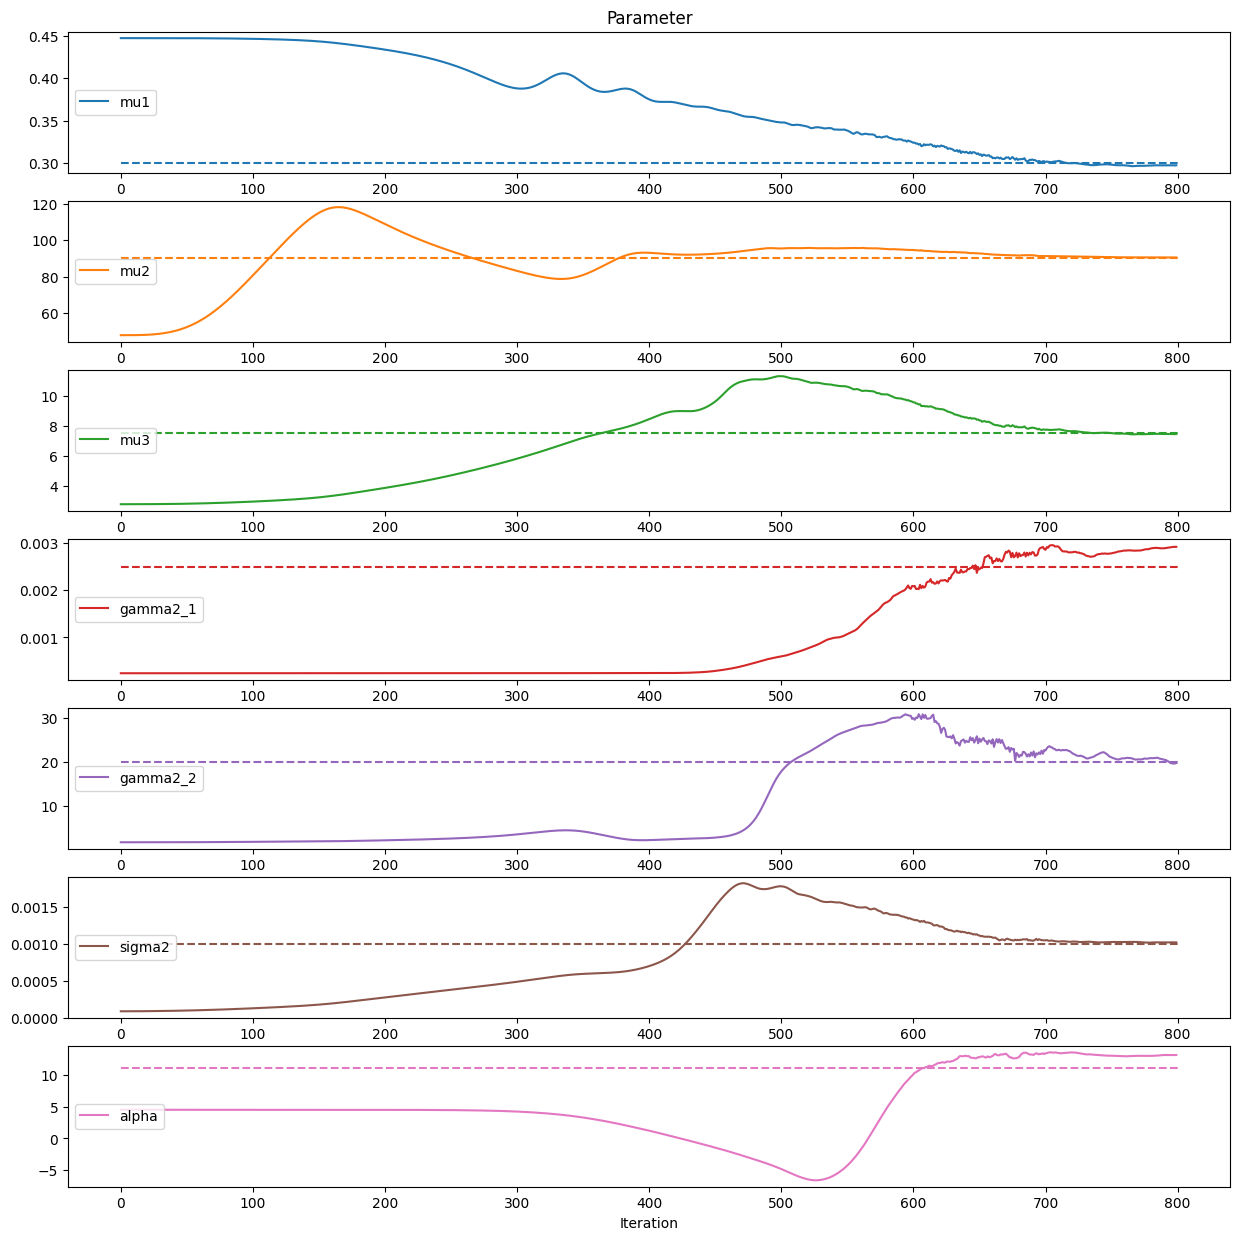

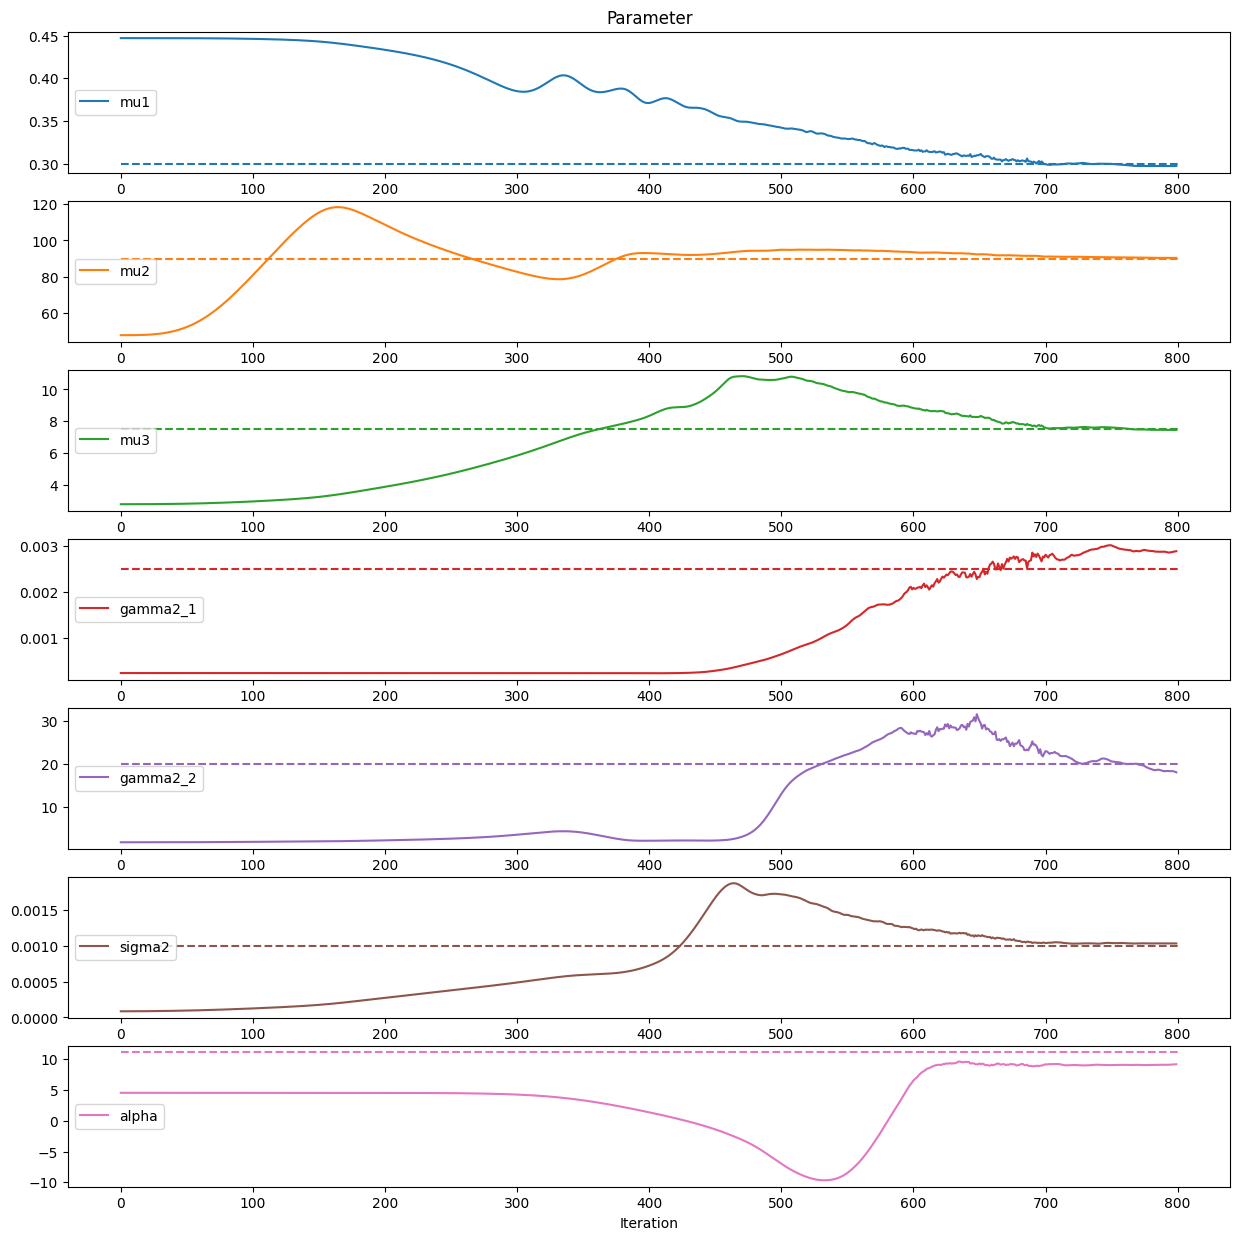

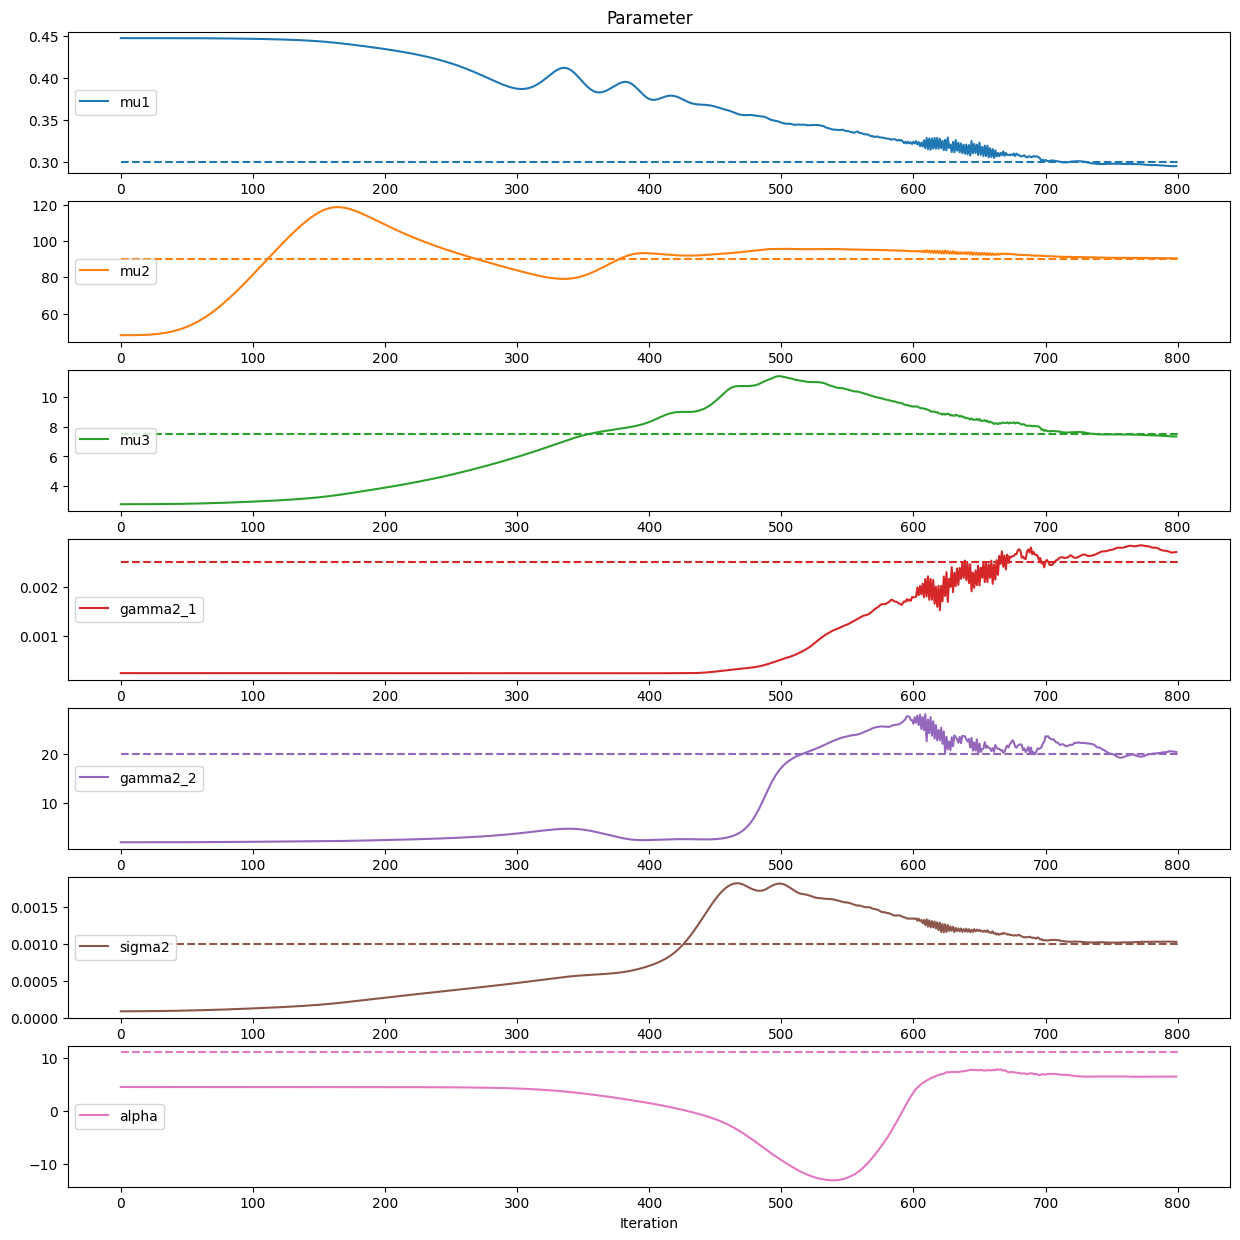

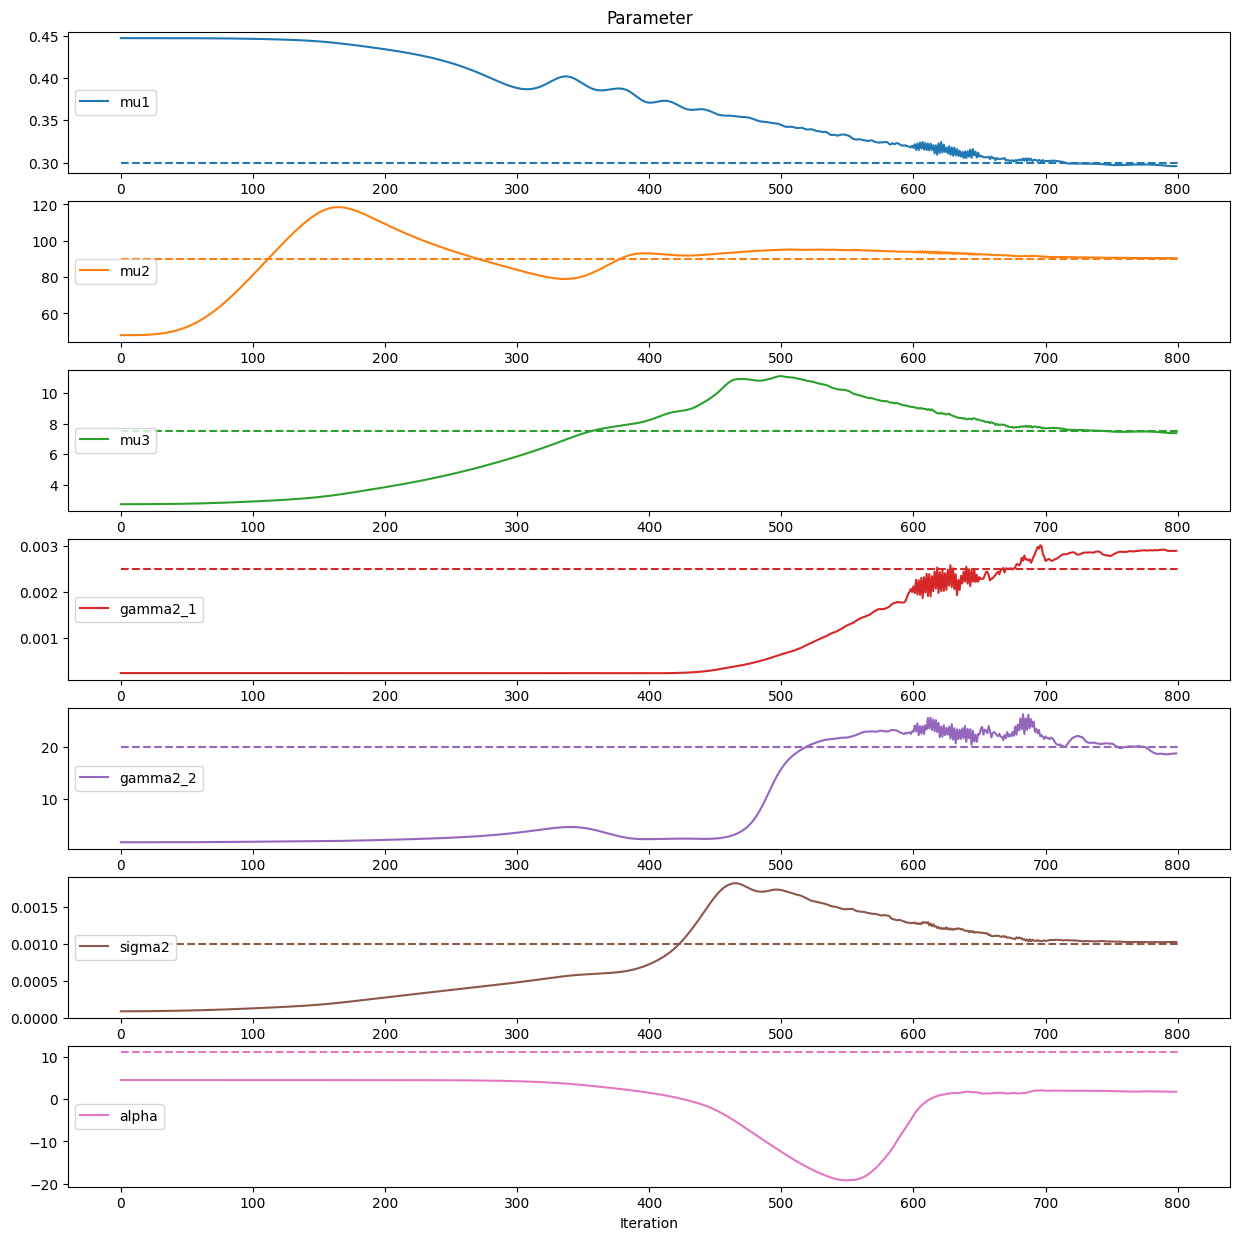

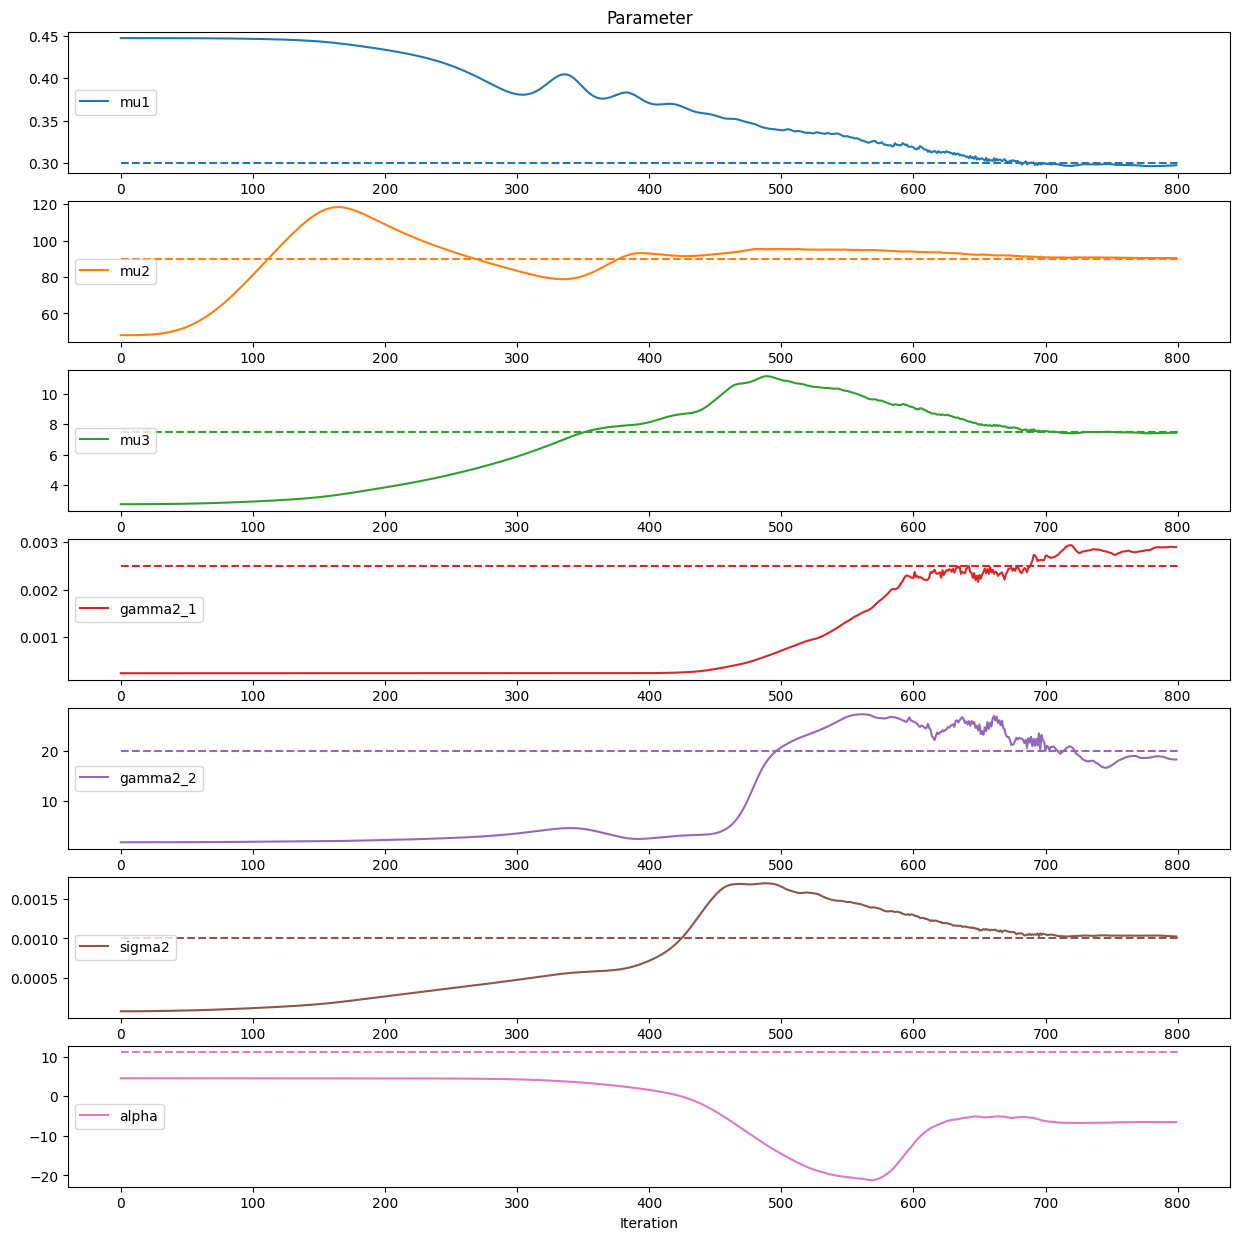

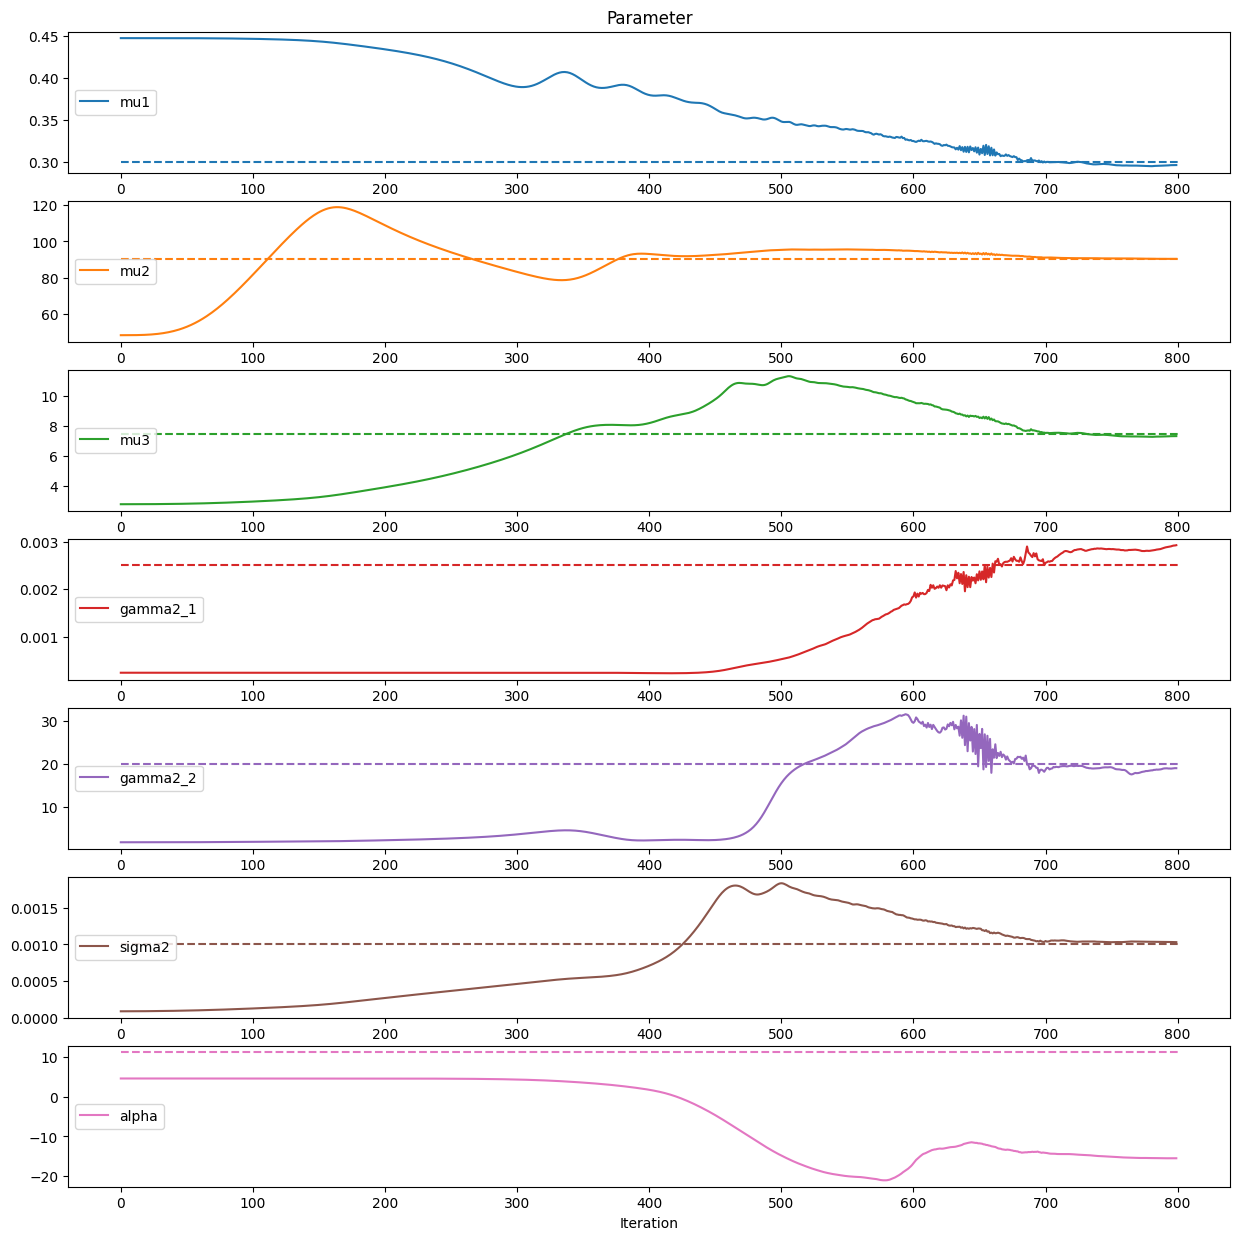

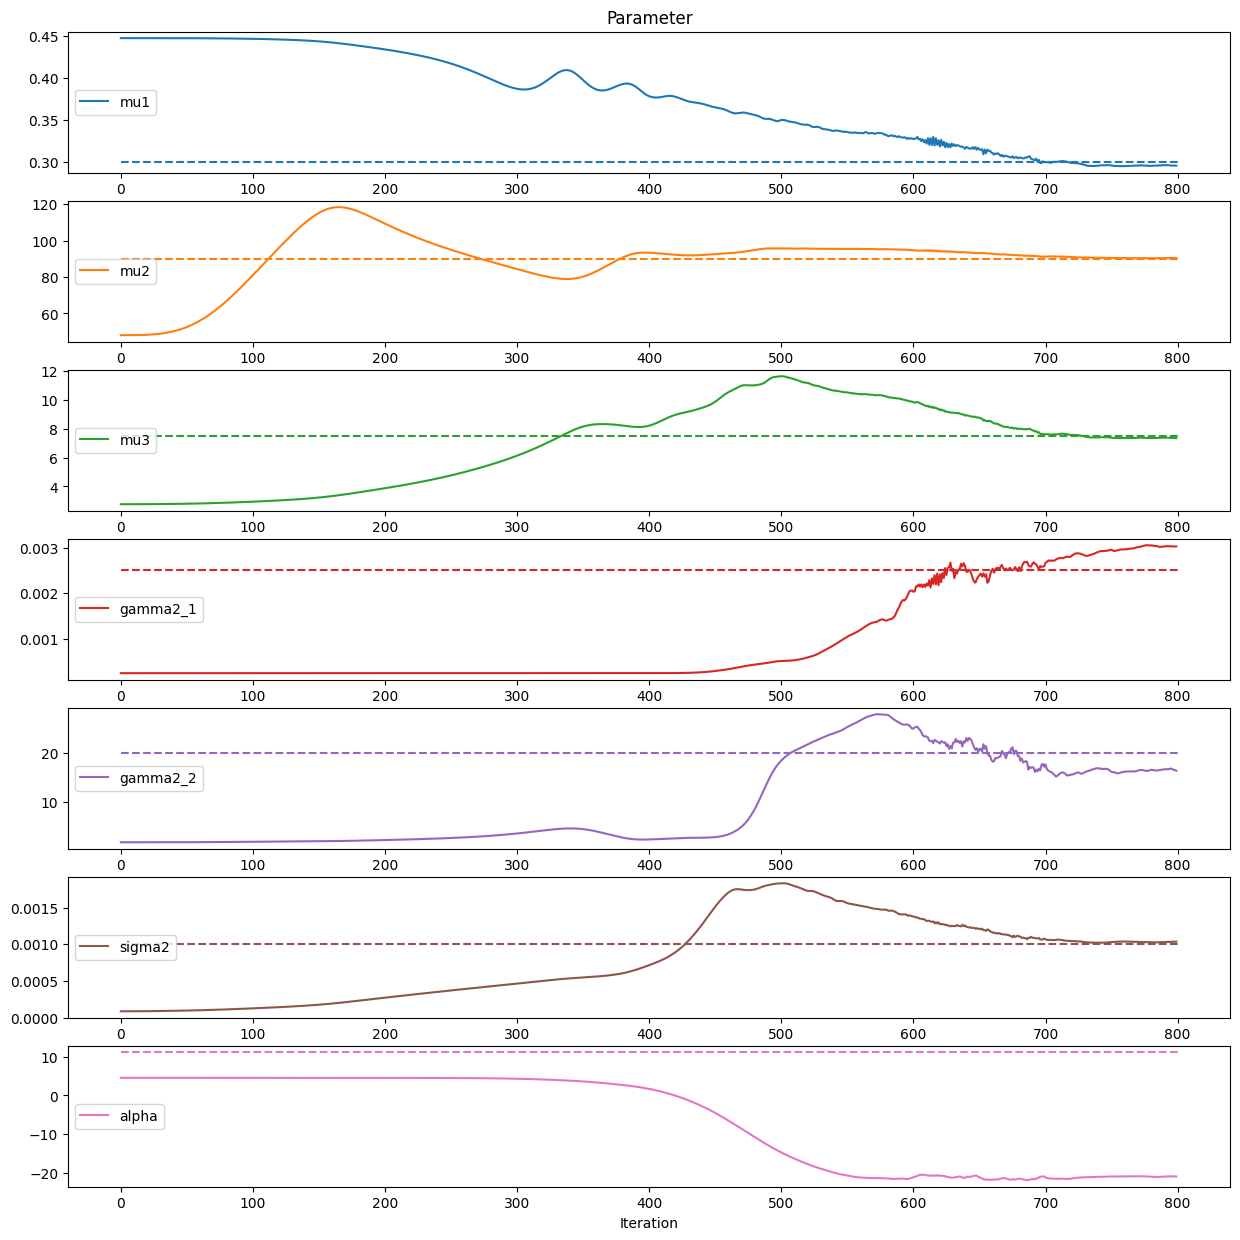

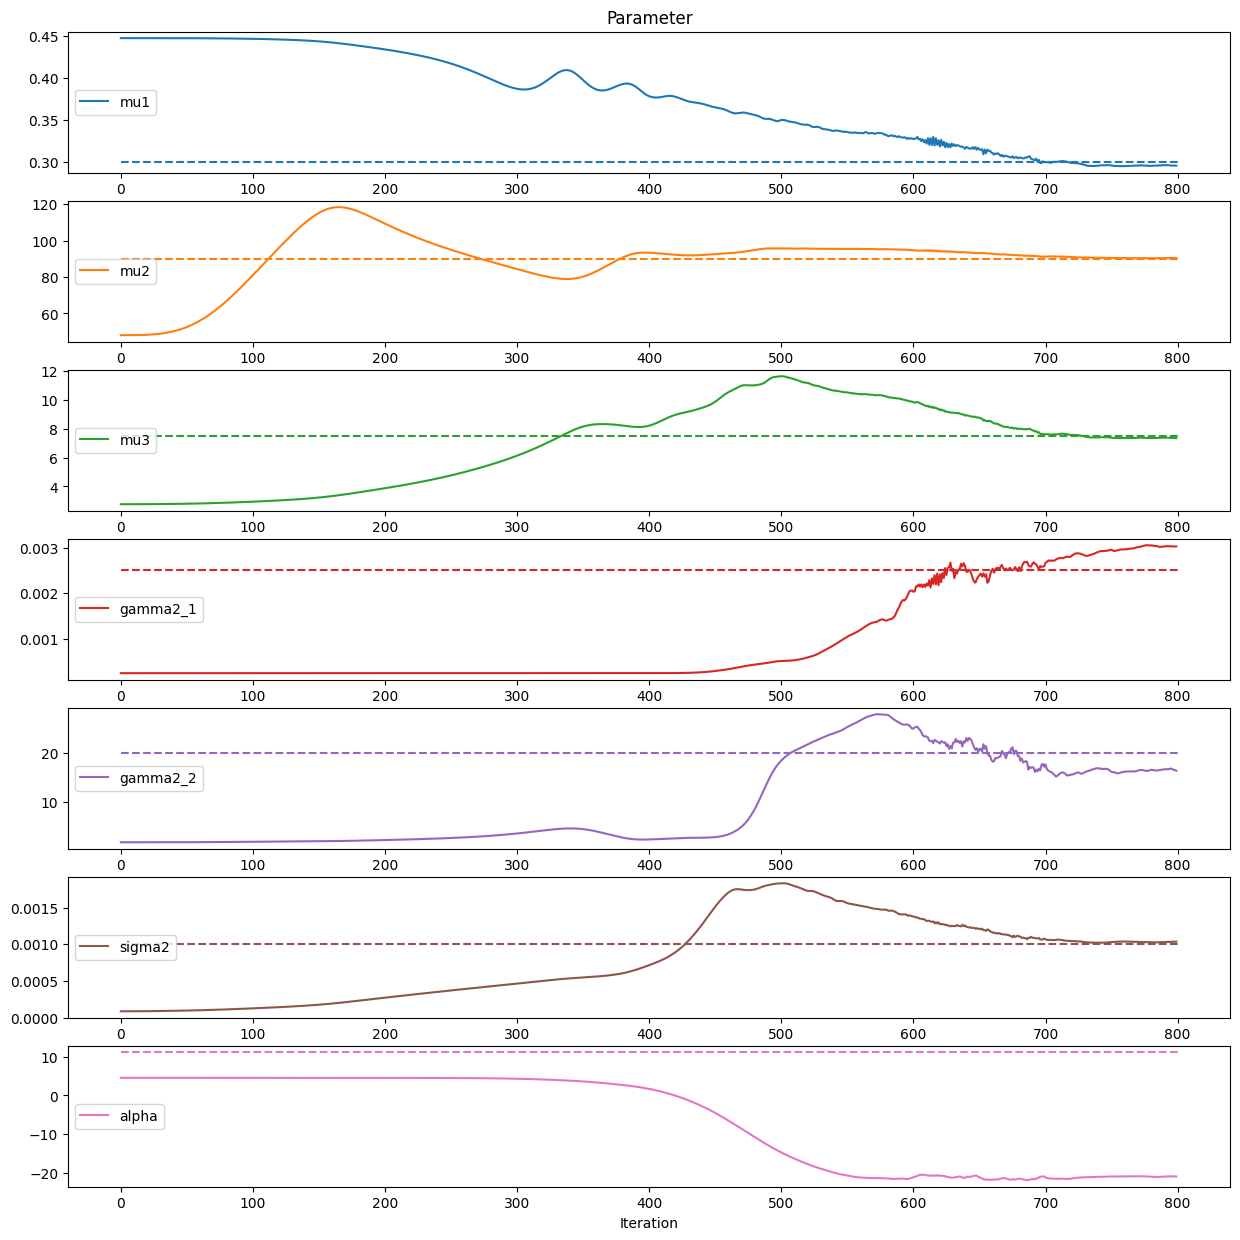

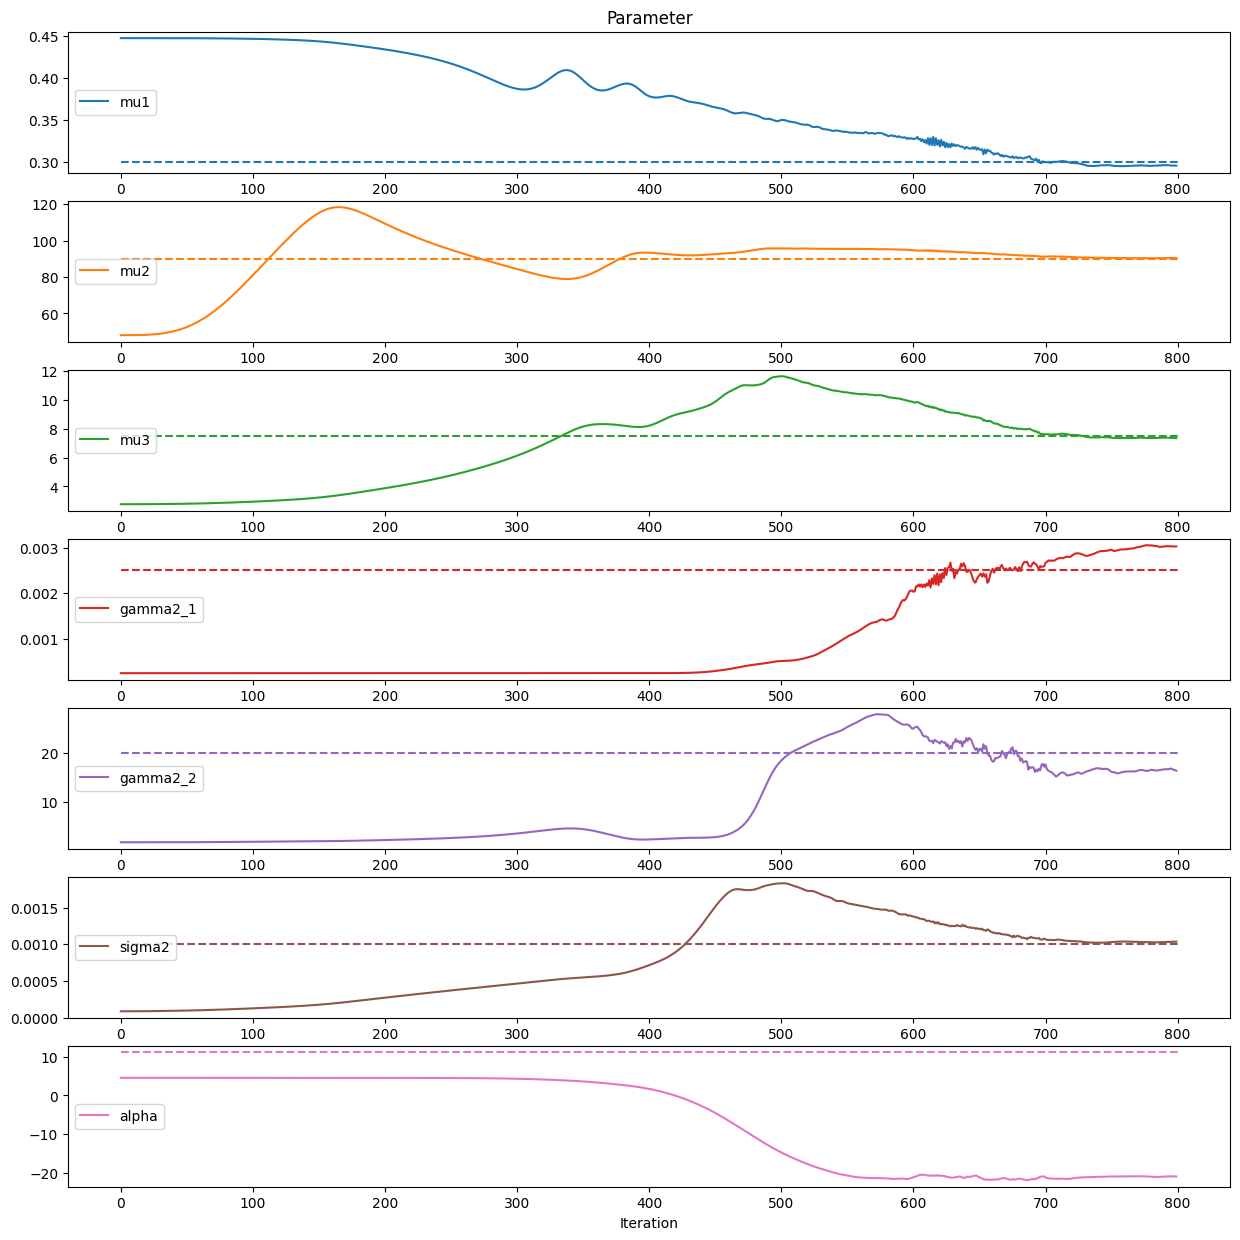

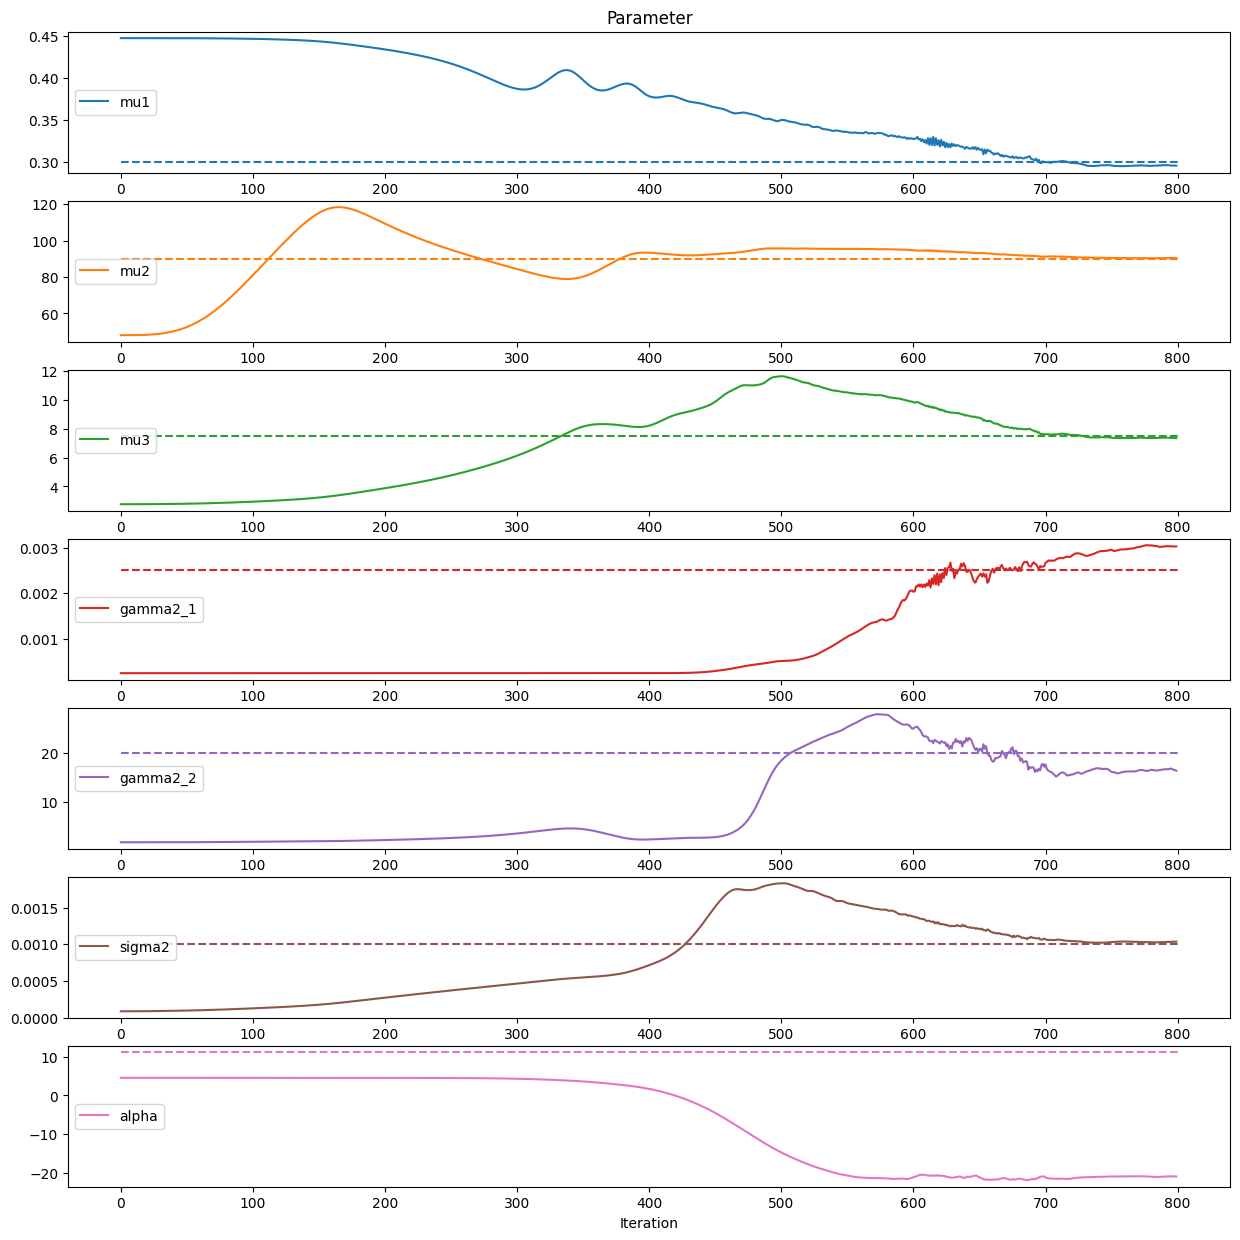

In [7]:

for res in lr[0]:
    _, _ = sdgplt.plot_params(
        x=res.theta,
        x_star=np.array(params_star_stack),
        p=DIM_COV,
        names=final_solver.params_names,
        logscale=False,
    )
